In [1]:

!pip install mediapipe==0.10.32 opencv-python-headless ultralytics librosa scikit-learn scipy -q

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf
import librosa
from scipy.signal import find_peaks, resample
from scipy.stats import skew, kurtosis
from ultralytics import YOLO
from google.colab import files
warnings.filterwarnings('ignore')

SELECTED_JOINTS       = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27]
WINDOW_SIZE           = 30
THRESHOLD             = 0.70
COOLDOWN_FRAMES       = 180
RACKET_MOVE_THRESHOLD = 20
MERGE_WINDOW_SEC      = 0.75

LABELS    = ['Forehand', 'Backhand', 'Serve']
LABEL_MAP = {0: 'Forehand', 1: 'Backhand', 2: 'Serve'}
GT_MAP    = {'F': 0, 'B': 1, 'S': 2}


V2_GT = [GT_MAP[x] for x in ['S','F','S','F','F','B','S','B','F','F','B','F']]

V3_GT = [GT_MAP[x] for x in ['S','F','B','F','F']]

print(" Imports ready")
print(f"   V2 GT: {len(V2_GT)} strokes")
print(f"   V3 GT: {len(V3_GT)} strokes")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Imports ready
   V2 GT: 12 strokes
   V3 GT: 5 strokes


In [2]:

print("\n1. Upload tennis_cnn_lstm_v1.h5")
u1 = files.upload()
camera_model = tf.keras.models.load_model(list(u1.keys())[0])
print(f" Camera CNN-LSTM — input: {camera_model.input_shape}")

print("\n2. Upload Au8dio_svm.pkl")
u2 = files.upload()
with open(list(u2.keys())[0], 'rb') as f:
    audio_data = pickle.load(f)
svm_audio    = audio_data['svm']
scaler_audio = audio_data['scaler']
N_MFCC_AUDIO = audio_data['n_mfcc']
CLIP_AUDIO   = audio_data['clip_duration']
print(f" Audio SVM — n_mfcc={N_MFCC_AUDIO}, clip={CLIP_AUDIO}s")

print("\n3. Upload accel_cnn_lstm_v4.h5")
u3 = files.upload()
accel_cnn = tf.keras.models.load_model(list(u3.keys())[0])
print(f" Accel CNN-LSTM — input: {accel_cnn.input_shape}")

print("\n4. Upload accel_svm_v4.pkl")
u4 = files.upload()
with open(list(u4.keys())[0], 'rb') as f:
    svm_data = pickle.load(f)
svm_model  = svm_data['model']
svm_scaler = svm_data['scaler']
print(" Accel SVM loaded")

print("\n5. Loading YOLOv8...")
yolo = YOLO('yolov8n.pt')
print(" YOLO loaded")


1. Upload tennis_cnn_lstm_v1.h5


Saving tennis_cnn_lstm_v1.h5 to tennis_cnn_lstm_v1.h5


 Camera CNN-LSTM — input: (None, 30, 22)

2. Upload Au8dio_svm.pkl


Saving Au8dio_svm.pkl to Au8dio_svm.pkl
 Audio SVM — n_mfcc=40, clip=0.5s

3. Upload accel_cnn_lstm_v4.h5


Saving accel_cnn_lstm_v4.h5 to accel_cnn_lstm_v4.h5
 Accel CNN-LSTM — input: (None, 60, 4)

4. Upload accel_svm_v4.pkl


Saving accel_svm_v4.pkl to accel_svm_v4.pkl
 Accel SVM loaded

5. Loading YOLOv8...
 YOLO loaded


In [3]:

print("\n VIDEO 2 ")
print("6. Upload session2.mp4")
uv2 = files.upload()
V2_VIDEO = list(uv2.keys())[0]
print(f" {V2_VIDEO}")

print("\n7. Upload results_2.csv")
ua2 = files.upload()
V2_ACCEL = list(ua2.keys())[0]
print(f" {V2_ACCEL}")

print("\n VIDEO 3 ")
print("8. Upload session3.mp4")
uv3 = files.upload()
V3_VIDEO = list(uv3.keys())[0]
print(f" {V3_VIDEO}")

print("\n9. Upload results_3.csv")
ua3 = files.upload()
V3_ACCEL = list(ua3.keys())[0]
print(f" {V3_ACCEL}")

print("\n All files uploaded")


 VIDEO 2 
6. Upload session2.mp4


Saving ss2.mp4 to ss2.mp4
 ss2.mp4

7. Upload results_2.csv


Saving results 2.csv to results 2.csv
 results 2.csv

 VIDEO 3 
8. Upload session3.mp4


Saving ss3.mp4 to ss3.mp4
 ss3.mp4

9. Upload results_3.csv


Saving results 3.csv to results 3.csv
 results 3.csv

 All files uploaded


In [4]:

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import urllib.request

MODEL_PATH = "pose_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task",
        MODEL_PATH
    )
    print(" Downloaded")

def make_pose_detector():
    opts = mp_vision.PoseLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp_vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.4,
        min_pose_presence_confidence=0.4,
        min_tracking_confidence=0.5
    )
    return mp_vision.PoseLandmarker.create_from_options(opts)

def extract_skeleton(pose_detector, frame):
    rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = pose_detector.detect(mp_img)
    if not result.pose_landmarks or len(result.pose_landmarks) == 0:
        return None
    lm  = result.pose_landmarks[0]
    return [[lm[i].x, lm[i].y] for i in SELECTED_JOINTS]

def hip_normalise_and_predict(buffer):
    """Mid-hip normalisation """
    seq    = np.array(buffer)
    hip_x  = (seq[:, 12] + seq[:, 14]) / 2.0
    hip_y  = (seq[:, 13] + seq[:, 15]) / 2.0
    seq_3d = seq.reshape(WINDOW_SIZE, 11, 2)
    hip_3d = np.stack([hip_x, hip_y], axis=1)[:, None, :]
    seq_3d = seq_3d - hip_3d
    probs  = camera_model.predict(seq_3d.reshape(1, WINDOW_SIZE, 22), verbose=0)[0]
    cls    = int(np.argmax(probs))
    return cls, float(probs[cls])

def get_racket_center(frame):
    results = yolo(frame, classes=[38], verbose=False)[0]
    best_conf, best_center = 0, None
    for box in results.boxes:
        conf = float(box.conf)
        if conf > 0.25 and conf > best_conf:
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            best_center  = ((x1+x2)//2, (y1+y2)//2)
            best_conf    = conf
    return best_center, best_conf


CLIP_SEC = 0.6
N_ACCEL  = 60

def load_accel(path):
    df = pd.read_csv(path, comment='#')
    df.columns = ['time', 'ax', 'ay', 'az', 'aT']
    return df

def get_accel_clip(df, t_center):
    t0, t1 = t_center - CLIP_SEC/2, t_center + CLIP_SEC/2
    c = df[(df.time >= t0) & (df.time < t1)]
    return c if len(c) >= 20 else None

def handcrafted_features(clip):
    feats = []
    for col in ['ax', 'ay', 'az', 'aT']:
        sig = clip[col].values
        pv  = np.max(np.abs(sig)) + 1e-8
        sn  = sig / pv
        feats += [np.mean(sn), np.std(sn), np.max(sn), np.min(sn),
                  np.max(sn)-np.min(sn), float(skew(sn)),
                  float(kurtosis(sn)), pv, np.sqrt(np.mean(sig**2))]
    aT = clip['aT'].values
    ax = clip['ax'].values
    feats.append(np.max(aT))
    feats.append(float(np.sum(np.diff(np.sign(ax))!=0)) / len(ax))
    feats.append(np.sum(aT**2) / len(aT))
    total = sum(np.mean(np.abs(clip[c].values)) for c in ['ax','ay','az']) + 1e-8
    for col in ['ax', 'ay', 'az']:
        feats.append(np.mean(np.abs(clip[col].values)) / total)
    return np.array(feats, dtype=np.float32)

def raw_window_accel(df, t_center):
    clip = get_accel_clip(df, t_center)
    if clip is None: return None
    raw  = clip[['ax','ay','az','aT']].values
    norm = raw / (np.max(np.abs(raw), axis=0) + 1e-8)
    return resample(norm, N_ACCEL, axis=0).astype(np.float32)

def detect_accel_standalone(csv_path, label="", skip_first=0):

    df = load_accel(csv_path)
    peak_times = []
    for col in ['ax', 'ay', 'az']:
        sig   = df[col].values
        sig_n = np.abs(sig) / (np.max(np.abs(sig)) + 1e-8)
        peaks, _ = find_peaks(sig_n, height=0.4, distance=50, prominence=0.2)
        for p in peaks:
            peak_times.append(df['time'].iloc[p])

    if not peak_times:
        print(f"    {label}: no peaks found"); return []

    peak_times = sorted(peak_times)
    stroke_times, cluster = [], [peak_times[0]]
    for t in peak_times[1:]:
        if t - cluster[-1] <= 0.3:
            cluster.append(t)
        else:
            stroke_times.append(np.mean(cluster))
            cluster = [t]
    stroke_times.append(np.mean(cluster))

    filtered = [stroke_times[0]]
    for t in stroke_times[1:]:
        if t - filtered[-1] >= 1.5:
            filtered.append(t)
    stroke_times = filtered[skip_first:]

    print(f"  Accel {label}: {len(stroke_times)} events (skipped first {skip_first})")

    detections = []
    for t_csv in stroke_times:
        clip = get_accel_clip(df, t_csv)
        rw   = raw_window_accel(df, t_csv)
        if clip is None or rw is None: continue
        feat     = handcrafted_features(clip)
        svm_pred = int(svm_model.predict(svm_scaler.transform([feat]))[0])
        svm_prob = float(svm_model.predict_proba(svm_scaler.transform([feat]))[0][svm_pred])
        cnn_prob = accel_cnn.predict(rw[np.newaxis], verbose=0)[0]
        cnn_pred = int(np.argmax(cnn_prob))
        cnn_conf = float(cnn_prob[cnn_pred])
        print(f"    t_csv={t_csv:.2f}s  "
              f"SVM:{LABELS[svm_pred]:<10}({svm_prob:.2f})  "
              f"CNN:{LABELS[cnn_pred]:<10}({cnn_conf:.2f})")
        detections.append((t_csv, svm_pred, svm_prob*100, cnn_pred, cnn_conf*100))
    return detections

def extract_audio_features(clip, sr):
    if len(clip) < sr * 0.1: return None
    try:
        mfcc   = librosa.feature.mfcc(y=clip, sr=sr, n_mfcc=N_MFCC_AUDIO)
        chroma = librosa.feature.chroma_stft(y=clip, sr=sr)
        zcr    = librosa.feature.zero_crossing_rate(clip)
        rmse   = librosa.feature.rms(y=clip)
        return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1),
                                chroma.mean(axis=1), zcr.mean(axis=1), rmse.mean(axis=1)])
    except:
        return None

def detect_audio(video_path, tmp_name):
    audio_tmp = f'/tmp/{tmp_name}.wav'
    os.system(f'ffmpeg -y -i "{video_path}" -q:a 0 -map a "{audio_tmp}" -loglevel quiet')
    if not os.path.exists(audio_tmp):
        print("    Audio extraction failed"); return []
    y, sr      = librosa.load(audio_tmp, sr=None)
    duration   = len(y) / sr
    detections, last_t = [], -1.0
    PROB_THRESH, MIN_GAP, STEP = 0.60, 1.5, 0.1
    t = CLIP_AUDIO / 2
    while t < duration - CLIP_AUDIO / 2:
        start = max(0, t - 0.1)
        clip  = y[int(start*sr):int(min(duration, t+CLIP_AUDIO)*sr)]
        feat  = extract_audio_features(clip, sr)
        if feat is not None:
            prob = svm_audio.predict_proba(scaler_audio.transform([feat]))[0][1]
            if prob >= PROB_THRESH and (t - last_t) >= MIN_GAP:
                detections.append((t, prob)); last_t = t
        t += STEP
    print(f" Audio: {len(detections)} contacts")
    print(f"   Times: {[round(d[0],2) for d in detections]}")
    return detections

def run_camera(video_path, output_suffix):

    pose_det = make_pose_detector()
    cap    = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS) or 60.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    output_name = video_path.replace('.mp4','') + output_suffix
    out = cv2.VideoWriter(output_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    print(f"  {fps:.0f}fps  {width}×{height}  {total} frames → {output_name}")

    skeleton_buffer    = []
    prev_skel          = None
    cam_detections     = []
    last_det_frame     = -COOLDOWN_FRAMES
    last_label         = None
    last_label_frame   = -999
    prev_racket_center = None
    racket_velocity    = 0.0
    racket_det_count   = 0
    frame_idx          = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        canvas = frame.copy()

        pts = extract_skeleton(pose_det, frame)
        if pts is None:
            pts = prev_skel if prev_skel is not None else [[0.0,0.0]]*len(SELECTED_JOINTS)
        prev_skel = pts
        skeleton_buffer.append(np.array(pts).flatten())
        if len(skeleton_buffer) > WINDOW_SIZE: skeleton_buffer.pop(0)

        racket_center, racket_conf = get_racket_center(frame)
        if racket_center is not None:
            racket_det_count += 1
            if prev_racket_center is not None:
                dx = racket_center[0] - prev_racket_center[0]
                dy = racket_center[1] - prev_racket_center[1]
                racket_velocity = np.sqrt(dx**2 + dy**2)
            else:
                racket_velocity = 0.0
            prev_racket_center = racket_center
        else:
            racket_velocity = 0.0
            prev_racket_center = None

        racket_swinging = (racket_velocity >= RACKET_MOVE_THRESHOLD
                           and racket_center is not None)

        if (racket_swinging
                and len(skeleton_buffer) == WINDOW_SIZE
                and (frame_idx - last_det_frame) >= COOLDOWN_FRAMES):
            cls, conf = hip_normalise_and_predict(skeleton_buffer)
            if conf >= THRESHOLD:
                t_sec = frame_idx / fps
                cam_detections.append((t_sec, cls, conf))
                last_det_frame = frame_idx
                last_label     = (cls, conf)
                last_label_frame = frame_idx
                print(f"  frame={frame_idx:5d}  t={t_sec:.2f}s  "
                      f"{LABEL_MAP[cls]:<10}  conf={conf:.3f}  "
                      f"racket_v={racket_velocity:.1f}px")


        for j in range(len(pts)):
            cv2.circle(canvas,
                       (int(pts[j][0]*width), int(pts[j][1]*height)),
                       5, (255,255,255), -1)

        if racket_center:
            col = (0,80,255) if racket_swinging else (0,200,255)
            cv2.circle(canvas, racket_center, 14, col, 3)
            cv2.putText(canvas, f"RACKET v={racket_velocity:.0f}px",
                        (racket_center[0]+16, racket_center[1]),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
            if racket_swinging:
                cv2.putText(canvas, "SWING!",
                            (racket_center[0]-20, racket_center[1]-20),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

        show = (last_label is not None and
                last_label_frame <= frame_idx < last_label_frame + WINDOW_SIZE)
        if show:
            cls_l, conf_l = last_label
            col = {0:(0,200,80),1:(0,80,200),2:(200,0,80)}[cls_l]
            cv2.putText(canvas, LABEL_MAP[cls_l].upper(), (80,140),
                        cv2.FONT_HERSHEY_SIMPLEX, 2.8, (0,0,0), 10)
            cv2.putText(canvas, LABEL_MAP[cls_l].upper(), (80,140),
                        cv2.FONT_HERSHEY_SIMPLEX, 2.8, col, 6)
            cv2.putText(canvas, f"conf={conf_l:.2f}", (80,190),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, col, 2)

        f_c = sum(1 for d in cam_detections if d[1]==0)
        b_c = sum(1 for d in cam_detections if d[1]==1)
        s_c = sum(1 for d in cam_detections if d[1]==2)
        cv2.putText(canvas, f"F:{f_c} B:{b_c} S:{s_c}",
                    (width-220,40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 4)
        cv2.putText(canvas, f"F:{f_c} B:{b_c} S:{s_c}",
                    (width-220,40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

        bar_w = min(int(racket_velocity*2), width//3)
        cv2.rectangle(canvas, (10,height-30),
                      (10+bar_w,height-10),
                      (0,0,255) if racket_swinging else (0,200,100), -1)
        cv2.putText(canvas, f"Racket v={racket_velocity:.0f}",
                    (10,height-35), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
        cv2.putText(canvas, f"t={frame_idx/fps:.2f}s",
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

        out.write(canvas)
        frame_idx += 1
        if frame_idx % 300 == 0:
            print(f"  Progress: {frame_idx}/{total} ({frame_idx/total*100:.0f}%)  "
                  f"Racket:{racket_det_count}  Strokes:{len(cam_detections)}")

    cap.release(); out.release(); pose_det.close()
    print(f"   Done — {frame_idx} frames  "
          f"Racket:{racket_det_count} ({racket_det_count/frame_idx*100:.1f}%)  "
          f"Strokes:{len(cam_detections)}")
    return cam_detections, output_name

def evaluate(label, gt, cam_det, acc_det, aud_det):
    n_gt = len(gt)
    n    = min(len(cam_det), n_gt)

    print(f"\nGround truth : {n_gt}  Camera:{len(cam_det)}  "
          f"Accel:{len(acc_det)}  Audio:{len(aud_det)}")

    # Camera alone
    print("\n" + "═"*55)
    print(f"CAMERA ALONE — {label}")
    print("═"*55)
    cc = 0
    for i in range(min(len(cam_det), n_gt)):
        t, cls, conf = cam_det[i]
        gt_cls = gt[i]
        mk = '✅' if cls == gt_cls else '❌'
        print(f"  {i+1:<2}  t={t:.2f}s  GT:{LABELS[gt_cls]:<10}  "
              f"Pred:{LABELS[cls]:<10}  {mk}  conf={conf:.2f}")
        if cls == gt_cls: cc += 1
    for i in range(len(cam_det), n_gt):
        print(f"  {i+1:<2}  MISSED  GT:{LABELS[gt[i]]}")
    print(f"\n  Camera: {cc}/{n_gt} = {cc/n_gt*100:.1f}%")

    # Accel alone
    print("\n" + "═"*55)
    print(f"ACCEL ALONE — {label}")
    print("═"*55)
    cs = cn = 0
    for i in range(min(len(acc_det), n_gt)):
        t_csv, sp, sc, cp, cc_val = acc_det[i]
        gt_cls = gt[i]
        mks = '✅' if sp == gt_cls else '❌'
        mkc = '✅' if cp == gt_cls else '❌'
        print(f"  {i+1:<2}  t_csv={t_csv:.2f}s  GT:{LABELS[gt_cls]:<10}  "
              f"SVM:{LABELS[sp]:<10}{mks}({sc:.0f}%)  "
              f"CNN:{LABELS[cp]:<10}{mkc}({cc_val:.0f}%)")
        if sp == gt_cls: cs += 1
        if cp == gt_cls: cn += 1
    for i in range(len(acc_det), n_gt):
        print(f"  {i+1:<2}  MISSED  GT:{LABELS[gt[i]]}")
    print(f"\n  Accel SVM : {cs}/{n_gt} = {cs/n_gt*100:.1f}%")
    print(f"  Accel CNN : {cn}/{n_gt} = {cn/n_gt*100:.1f}%")

    # Audio
    audio_recall = len(aud_det) / n_gt * 100
    print(f"\n  Audio recall: {len(aud_det)}/{n_gt} = {audio_recall:.1f}%")

    # Fusion
    print("\n" + "═"*55)
    print(f"FUSION — {label}")
    print("═"*55)
    cf = 0
    nf = min(len(cam_det), len(acc_det), n_gt)
    for i in range(nf):
        t_cam, cam_cls, cam_conf  = cam_det[i]
        t_csv, sp, sc, cp, cc_val = acc_det[i]
        gt_cls = gt[i]
        votes = np.zeros(3)
        votes[cam_cls] += 2.0 * cam_conf
        votes[cp]      += 2.0 * (cc_val/100)
        votes[sp]      += 1.0 * (sc/100)
        votes /= np.sum(votes)
        fusion_cls = int(np.argmax(votes))
        aud_ok = any(abs(t_a - t_cam) <= MERGE_WINDOW_SEC for t_a,_ in aud_det)
        mk  = '✅' if fusion_cls == gt_cls else '❌'
        aud = '🎵' if aud_ok else '  '
        print(f"  {i+1:<2}  GT:{LABELS[gt_cls]:<10}  "
              f"Cam:{LABELS[cam_cls]:<10}  "
              f"CNN:{LABELS[cp]:<10}  "
              f"SVM:{LABELS[sp]:<10}  "
              f"→ FUSION:{LABELS[fusion_cls]:<10}{mk}  {aud}")
        if fusion_cls == gt_cls: cf += 1
    for i in range(nf, n_gt):
        print(f"  {i+1:<2}  MISSED  GT:{LABELS[gt[i]]}")

    print(f"\n  Camera alone : {cc}/{n_gt} = {cc/n_gt*100:.1f}%")
    print(f"  Accel SVM    : {cs}/{n_gt} = {cs/n_gt*100:.1f}%")
    print(f"  Accel CNN    : {cn}/{n_gt} = {cn/n_gt*100:.1f}%")
    print(f"  FUSION       : {cf}/{n_gt} = {cf/n_gt*100:.1f}%  ← REPORT THIS")
    print(f"  Audio recall : {len(aud_det)}/{n_gt} = {audio_recall:.1f}%")
    print("═"*55)
    return cc, cs, cn, cf, n_gt, audio_recall

def metrics_and_plots(label, gt, cam_det, acc_det, suffix):
    from sklearn.metrics import (precision_score, recall_score, f1_score,
                                 confusion_matrix, ConfusionMatrixDisplay)
    import matplotlib.pyplot as plt

    n = min(len(cam_det), len(acc_det), len(gt))
    y_true = gt[:n]
    y_cam  = [cam_det[i][1] for i in range(n)]
    y_svm  = [acc_det[i][1] for i in range(n)]
    y_cnn  = [acc_det[i][3] for i in range(n)]
    y_fusion = []
    for i in range(n):
        t_cam, cam_cls, cam_conf  = cam_det[i]
        t_csv, sp, sc, cp, cc_val = acc_det[i]
        votes = np.zeros(3)
        votes[cam_cls] += 2.0 * cam_conf
        votes[cp]      += 2.0 * (cc_val/100)
        votes[sp]      += 1.0 * (sc/100)
        votes /= np.sum(votes)
        y_fusion.append(int(np.argmax(votes)))

    print(f"\nMETRICS — {label}")
    for name, y_pred in [("Camera CNN-LSTM", y_cam),
                          ("Accel SVM",       y_svm),
                          ("Accel CNN-LSTM",  y_cnn),
                          ("FUSION",          y_fusion)]:
        p = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        r = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
        f = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
        print(f"  {name:<20}  P={p:.2f}  R={r:.2f}  F1={f:.2f}")

    cm = confusion_matrix(y_true, y_fusion, labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5,4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Fusion Confusion Matrix — {label}")
    plt.tight_layout()
    plt.savefig(f"fusion_confusion_{suffix}.png", dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(14,3))
    ax.eventplot([d[0] for d in cam_det],  lineoffsets=2, linelengths=0.6,
                 colors='green',  label='Camera (video clock)')
    ax.eventplot([d[0] for d in acc_det],  lineoffsets=1, linelengths=0.6,
                 colors='orange', label='Accel (CSV clock)')
    ax.set_yticks([1,2]); ax.set_yticklabels(['Accel','Camera'])
    ax.set_xlabel("Time (s)"); ax.set_title(f"Timeline — {label}")
    ax.legend(); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"fusion_timeline_{suffix}.png", dpi=150); plt.show()
    print(f" Plots saved for {suffix}")

print(" All helper functions defined")


 Downloaded
 All helper functions defined


In [5]:

print("\n V2 Audio")
aud_det_v2 = detect_audio(V2_VIDEO, 'aud_v2')


 V2 Audio
 Audio: 17 contacts
   Times: [1.35, 2.85, 4.35, 6.45, 8.35, 9.95, 11.65, 14.45, 16.35, 21.75, 26.65, 28.75, 30.35, 32.15, 33.65, 35.25, 36.75]


In [6]:

print("\n V2 Accel")
acc_det_v2 = detect_accel_standalone(V2_ACCEL, "V2", skip_first=0)
print(f"  Accel V2: {len(acc_det_v2)} detected  GT: {len(V2_GT)}")
if len(acc_det_v2) > len(V2_GT):
    print(f"    {len(acc_det_v2)-len(V2_GT)} extra peaks")


 V2 Accel
  Accel V2: 13 events (skipped first 0)
    t_csv=16.68s  SVM:Serve     (0.91)  CNN:Serve     (1.00)
    t_csv=19.25s  SVM:Forehand  (0.97)  CNN:Forehand  (1.00)
    t_csv=25.77s  SVM:Serve     (0.99)  CNN:Serve     (1.00)
    t_csv=29.05s  SVM:Forehand  (0.91)  CNN:Forehand  (1.00)
    t_csv=31.81s  SVM:Forehand  (0.95)  CNN:Forehand  (1.00)
    t_csv=35.77s  SVM:Forehand  (0.63)  CNN:Backhand  (1.00)
    t_csv=54.34s  SVM:Serve     (0.97)  CNN:Serve     (1.00)
    t_csv=57.38s  SVM:Backhand  (0.91)  CNN:Backhand  (1.00)
    t_csv=60.97s  SVM:Forehand  (0.84)  CNN:Forehand  (1.00)
    t_csv=64.54s  SVM:Forehand  (0.91)  CNN:Forehand  (1.00)
    t_csv=67.46s  SVM:Backhand  (0.69)  CNN:Backhand  (1.00)
    t_csv=71.08s  SVM:Forehand  (0.71)  CNN:Forehand  (0.97)
    t_csv=73.00s  SVM:Forehand  (0.58)  CNN:Serve     (1.00)
  Accel V2: 13 detected  GT: 12
    1 extra peaks


In [7]:

print("\n V2 Camera")
cam_det_v2, v2_output = run_camera(V2_VIDEO, '_fusion_yolo_v2.mp4')


 V2 Camera
  59fps  2340×1080  2260 frames → ss2_fusion_yolo_v2.mp4
  frame=   64  t=1.08s  Serve       conf=0.998  racket_v=28.9px
  frame=  244  t=4.11s  Forehand    conf=1.000  racket_v=26.4px
  Progress: 300/2260 (13%)  Racket:114  Strokes:2
  frame=  544  t=9.16s  Forehand    conf=1.000  racket_v=20.6px
  Progress: 600/2260 (27%)  Racket:228  Strokes:3
  frame=  728  t=12.26s  Forehand    conf=1.000  racket_v=20.2px
  Progress: 900/2260 (40%)  Racket:258  Strokes:4
  frame=  942  t=15.86s  Forehand    conf=1.000  racket_v=23.6px
  frame= 1151  t=19.38s  Serve       conf=0.841  racket_v=22.1px
  Progress: 1200/2260 (53%)  Racket:377  Strokes:6
  frame= 1365  t=22.99s  Forehand    conf=1.000  racket_v=26.9px
  Progress: 1500/2260 (66%)  Racket:463  Strokes:7
  frame= 1569  t=26.42s  Forehand    conf=1.000  racket_v=21.5px
  Progress: 1800/2260 (80%)  Racket:549  Strokes:8
  frame= 1971  t=33.19s  Forehand    conf=1.000  racket_v=25.6px
  Progress: 2100/2260 (93%)  Racket:601  Strok


═════════════════════════════════════════════════════════════════
VIDEO 2 EVALUATION — Player 1
═════════════════════════════════════════════════════════════════

Ground truth : 12  Camera:10  Accel:13  Audio:17

═══════════════════════════════════════════════════════
CAMERA ALONE — Video 2 — Player 1
═══════════════════════════════════════════════════════
  1   t=1.08s  GT:Serve       Pred:Serve       ✅  conf=1.00
  2   t=4.11s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  3   t=9.16s  GT:Serve       Pred:Forehand    ❌  conf=1.00
  4   t=12.26s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  5   t=15.86s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  6   t=19.38s  GT:Backhand    Pred:Serve       ❌  conf=0.84
  7   t=22.99s  GT:Serve       Pred:Forehand    ❌  conf=1.00
  8   t=26.42s  GT:Backhand    Pred:Forehand    ❌  conf=1.00
  9   t=33.19s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  10  t=36.46s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  11  MISSED  GT:Backhand
  12  M

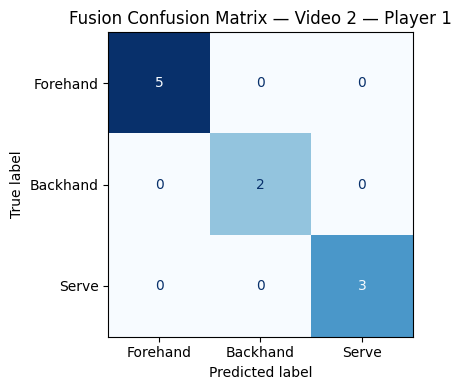

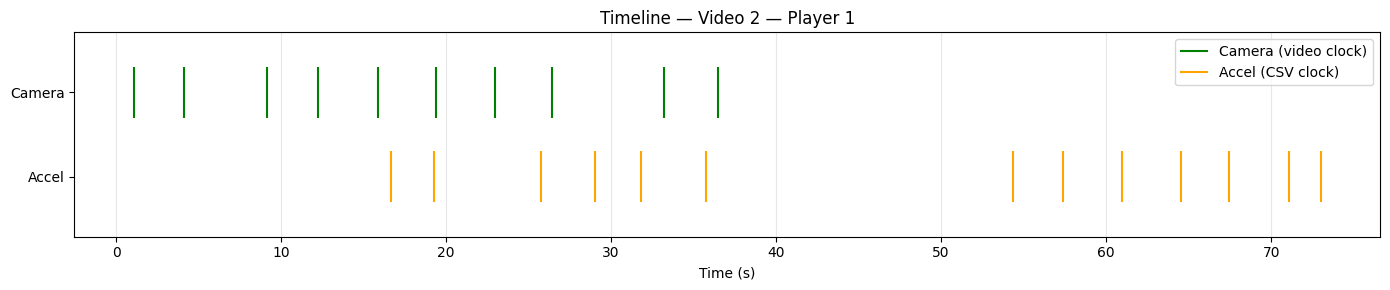

 Plots saved for v2

═══════════════════════════════════════════════════════
WHOOP DATA — Video 2 (Player 1)
═══════════════════════════════════════════════════════
  Avg HR: 147
  Max HR: 178
  Strain: 4.6
  Calories: 23


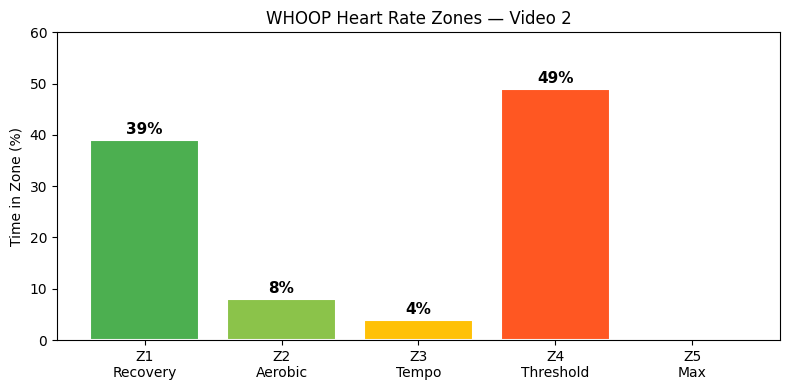

 Saved whoop_zones_v2.png


In [8]:

print("\n" + "═"*65)
print("VIDEO 2 EVALUATION — Player 1")
print("═"*65)
v2_results = evaluate("Video 2 — Player 1",
                       V2_GT, cam_det_v2, acc_det_v2, aud_det_v2)
metrics_and_plots("Video 2 — Player 1", V2_GT, cam_det_v2, acc_det_v2, "v2")


print("\n" + "═"*55)
print("WHOOP DATA — Video 2 (Player 1)")
print("═"*55)
import matplotlib.pyplot as plt
whoop = {'Avg HR':147,'Max HR':178,'Strain':4.6,'Calories':23}
for k,v in whoop.items(): print(f"  {k}: {v}")
zones  = [39, 8, 4, 49, 0]
zlbls  = ['Z1\nRecovery','Z2\nAerobic','Z3\nTempo','Z4\nThreshold','Z5\nMax']
colors = ['#4CAF50','#8BC34A','#FFC107','#FF5722','#B71C1C']
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(zlbls, zones, color=colors, edgecolor='white', linewidth=1.5)
for bar,val in zip(bars,zones):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel("Time in Zone (%)"); ax.set_ylim(0,60)
ax.set_title("WHOOP Heart Rate Zones — Video 2")
plt.tight_layout()
plt.savefig("whoop_zones_v2.png", dpi=150); plt.show()
print(" Saved whoop_zones_v2.png")


In [9]:

print("\n V3 Audio")
aud_det_v3 = detect_audio(V3_VIDEO, 'aud_v3')


print("\n V3 Accel...")
acc_det_v3 = detect_accel_standalone(V3_ACCEL, "V3", skip_first=0)
print(f"  Accel V3: {len(acc_det_v3)} detected  GT: {len(V3_GT)}")
if len(acc_det_v3) > len(V3_GT):
    print(f"    {len(acc_det_v3)-len(V3_GT)} extra peaks")



 V3 Audio
 Audio: 4 contacts
   Times: [1.35, 2.85, 4.95, 6.55]

 V3 Accel...
  Accel V3: 5 events (skipped first 0)
    t_csv=11.88s  SVM:Serve     (0.58)  CNN:Serve     (1.00)
    t_csv=15.00s  SVM:Serve     (0.90)  CNN:Forehand  (0.93)
    t_csv=19.13s  SVM:Backhand  (0.76)  CNN:Backhand  (1.00)
    t_csv=23.44s  SVM:Forehand  (0.53)  CNN:Forehand  (0.89)
    t_csv=27.48s  SVM:Forehand  (0.56)  CNN:Forehand  (1.00)
  Accel V3: 5 detected  GT: 5


In [10]:

print("\n V3 Camera")
cam_det_v3, v3_output = run_camera(V3_VIDEO, '_fusion_yolo_v3.mp4')


 V3 Camera
  60fps  2340×1080  1145 frames → ss3_fusion_yolo_v3.mp4
  frame=   29  t=0.48s  Forehand    conf=1.000  racket_v=26.1px
  frame=  225  t=3.76s  Forehand    conf=1.000  racket_v=53.9px
  Progress: 300/1145 (26%)  Racket:140  Strokes:2
  frame=  464  t=7.75s  Forehand    conf=1.000  racket_v=23.0px
  Progress: 600/1145 (52%)  Racket:205  Strokes:3
  frame=  723  t=12.08s  Forehand    conf=1.000  racket_v=48.8px
  Progress: 900/1145 (79%)  Racket:278  Strokes:4
  frame= 1002  t=16.74s  Forehand    conf=1.000  racket_v=29.8px
   Done — 1145 frames  Racket:380 (33.2%)  Strokes:5



═════════════════════════════════════════════════════════════════
VIDEO 3 EVALUATION — Player 2
═════════════════════════════════════════════════════════════════

Ground truth : 5  Camera:5  Accel:5  Audio:4

═══════════════════════════════════════════════════════
CAMERA ALONE — Video 3 — Player 2
═══════════════════════════════════════════════════════
  1   t=0.48s  GT:Serve       Pred:Forehand    ❌  conf=1.00
  2   t=3.76s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  3   t=7.75s  GT:Backhand    Pred:Forehand    ❌  conf=1.00
  4   t=12.08s  GT:Forehand    Pred:Forehand    ✅  conf=1.00
  5   t=16.74s  GT:Forehand    Pred:Forehand    ✅  conf=1.00

  Camera: 3/5 = 60.0%

═══════════════════════════════════════════════════════
ACCEL ALONE — Video 3 — Player 2
═══════════════════════════════════════════════════════
  1   t_csv=11.88s  GT:Serve       SVM:Serve     ✅(58%)  CNN:Serve     ✅(100%)
  2   t_csv=15.00s  GT:Forehand    SVM:Serve     ❌(90%)  CNN:Forehand  ✅(93%)
  3   t_csv=19.1

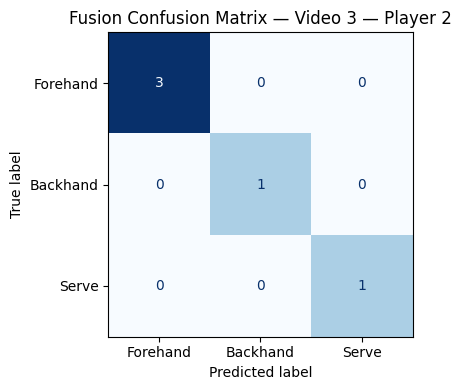

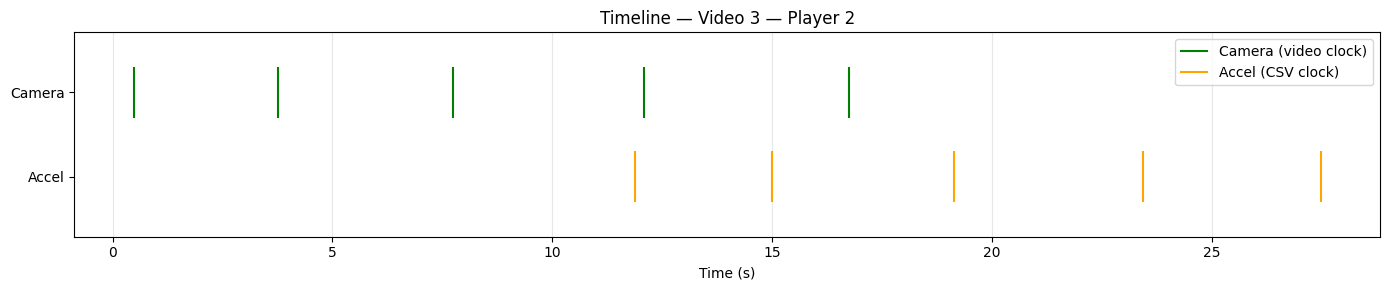

 Plots saved for v3


In [11]:

print("\n" + "═"*65)
print("VIDEO 3 EVALUATION — Player 2")
print("═"*65)
v3_results = evaluate("Video 3 — Player 2",
                       V3_GT, cam_det_v3, acc_det_v3, aud_det_v3)
metrics_and_plots("Video 3 — Player 2", V3_GT, cam_det_v3, acc_det_v3, "v3")

In [12]:

print("\n" + "═"*65)
print("COMBINED SUMMARY — V2 + V3")
print("═"*65)
cc2, cs2, cn2, cf2, ng2, ar2 = v2_results
cc3, cs3, cn3, cf3, ng3, ar3 = v3_results
total_gt = ng2 + ng3
print(f"\n{'Modality':<22}  {'V2 P1':>8}  {'V3 P2':>8}  {'Combined':>10}")
print("─"*55)
for name, a2, a3 in [
    ("Camera CNN-LSTM", cc2, cc3),
    ("Accel SVM",       cs2, cs3),
    ("Accel CNN-LSTM",  cn2, cn3),
    ("FUSION",          cf2, cf3),
]:
    combined = (a2+a3)/total_gt*100
    print(f"  {name:<20}  {a2/ng2*100:>7.1f}%  {a3/ng3*100:>7.1f}%  {combined:>9.1f}%")

audio_combined = (ar2*ng2/100 + ar3*ng3/100) / total_gt * 100
print(f"  {'Audio Recall':<20}  {ar2:>7.1f}%  {ar3:>7.1f}%  {audio_combined:>9.1f}%")
print("═"*65)
print(f"\n  FUSIO report")


═════════════════════════════════════════════════════════════════
COMBINED SUMMARY — V2 + V3
═════════════════════════════════════════════════════════════════

Modality                   V2 P1     V3 P2    Combined
───────────────────────────────────────────────────────
  Camera CNN-LSTM          50.0%     60.0%       52.9%
  Accel SVM                91.7%     80.0%       88.2%
  Accel CNN-LSTM          100.0%    100.0%      100.0%
  FUSION                   83.3%    100.0%       88.2%
  Audio Recall            141.7%     80.0%      123.5%
═════════════════════════════════════════════════════════════════

  FUSIO report


In [13]:

files.download(v2_output)
files.download(v3_output)
print(" Done")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done
